# Netflix Movie Data Analysis Project

In [14]:
df=pd.read_csv('/Users/apple/Downloads/mymoviedb.csv',lineterminator='\n')

In [114]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,release_Date,genre
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction",2021-12-15,"[Action, Adventure, Science Fiction]"
1,1970,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller",2022-03-01,"[Crime, Mystery, Thriller]"
2,1970,No Exit,2618.087,122,below_avg,Thriller,2022-02-25,[Thriller]
3,1970,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy",2021-11-24,"[Animation, Comedy, Family, Fantasy]"
4,1970,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War",2021-12-22,"[Action, Adventure, Thriller, War]"


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 4.5 MB


In [21]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: str

In [22]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9822    False
9823    False
9824    False
9825    False
9826    False
Length: 9827, dtype: bool

In [23]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [87]:

df['Release_Date']=pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtype)

datetime64[ns]


In [88]:
df['Release_Date']=pd.to_datetime(df['Release_Date'],errors='coerce')
df['Release_Date']=df['Release_Date'].dt.year

df['Release_Date'].dtypes


dtype('int32')

In [40]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,release_Date
0,1970,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021-12-15
1,1970,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022-03-01
2,1970,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022-02-25
3,1970,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021-11-24
4,1970,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021-12-22


Dropping  the columns

In [48]:
cols=['Overview','Original_Language','Poster_Url']

In [49]:
df.drop(cols,axis=1,inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre', 'release_Date'],
      dtype='str')

In [50]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,release_Date
0,1970,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",2021-12-15
1,1970,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",2022-03-01
2,1970,No Exit,2618.087,122,6.3,Thriller,2022-02-25
3,1970,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",2021-11-24
4,1970,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",2021-12-22


Categorize vote_Average columns

In [71]:
def categorize_col(df,col,labels):
    edges=[df[col].describe()['min'],
          df[col].describe()['25%'],
          df[col].describe()['50%'],
          df[col].describe()['75%'],
          df[col].describe()['max']]
    df[col]= pd.cut(df[col],edges,labels=labels,duplicates='drop')
    return df

In [72]:
labels=['not_popular','below_avg','average','popular']
categorize_col(df,'Vote_Average',labels)
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, str): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [74]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,release_Date
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction",2021-12-15
1,1970,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller",2022-03-01
2,1970,No Exit,2618.087,122,below_avg,Thriller,2022-02-25
3,1970,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy",2021-11-24
4,1970,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War",2021-12-22


In [75]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [76]:
df.dropna(inplace=True)
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
release_Date    0
dtype: int64

In [77]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,release_Date
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction",2021-12-15
1,1970,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller",2022-03-01
2,1970,No Exit,2618.087,122,below_avg,Thriller,2022-02-25
3,1970,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy",2021-11-24
4,1970,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War",2021-12-22


In [78]:
df['genre']=df['Genre'].str.split(',')
df=df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,release_Date,genre
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction",2021-12-15,"[Action, Adventure, Science Fiction]"
1,1970,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller",2022-03-01,"[Crime, Mystery, Thriller]"
2,1970,No Exit,2618.087,122,below_avg,Thriller,2022-02-25,[Thriller]
3,1970,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy",2021-11-24,"[Animation, Comedy, Family, Fantasy]"
4,1970,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War",2021-12-22,"[Action, Adventure, Thriller, War]"


In [79]:
# casting column into category
df['Genre']=df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Action, Adventure',
                  'Action, Adventure, Animation',
                  'Action, Adventure, Animation, Comedy',
                  'Action, Adventure, Animation, Comedy, Family',
                  'Action, Adventure, Animation, Comedy, Romance',
                  'Action, Adventure, Animation, Crime, Family, Mystery',
                  'Action, Adventure, Animation, Drama',
                  'Action, Adventure, Animation, Family',
                  'Action, Adventure, Animation, Family, Comedy',
                  ...
                  'Western, Drama', 'Western, Drama, Action, Adventure',
                  'Western, Drama, Adventure', 'Western, Drama, Crime',
                  'Western, Drama, History', 'Western, Drama, Mystery',
                  'Western, History', 'Western, Horror',
                  'Western, Mystery, Thriller, Drama', 'Western, Thriller'],
, ordered=False, categories_dtype=str)

In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9727 entries, 0 to 9726
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Release_Date  9727 non-null   int32         
 1   Title         9727 non-null   str           
 2   Popularity    9727 non-null   float64       
 3   Vote_Count    9727 non-null   int64         
 4   Vote_Average  9727 non-null   category      
 5   Genre         9727 non-null   category      
 6   release_Date  9727 non-null   datetime64[us]
 7   genre         9727 non-null   object        
dtypes: category(2), datetime64[us](1), float64(1), int32(1), int64(1), object(1), str(1)
memory usage: 704.8+ KB


In [82]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,release_Date,genre
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction",2021-12-15,"[Action, Adventure, Science Fiction]"
1,1970,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller",2022-03-01,"[Crime, Mystery, Thriller]"
2,1970,No Exit,2618.087,122,below_avg,Thriller,2022-02-25,[Thriller]
3,1970,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy",2021-11-24,"[Animation, Comedy, Family, Fantasy]"
4,1970,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War",2021-12-22,"[Action, Adventure, Thriller, War]"


Data Visualization

In [89]:
sns.set_style('whitegrid')

In [90]:
df['Genre'].describe()

count      9727
unique     2324
top       Drama
freq        458
Name: Genre, dtype: object

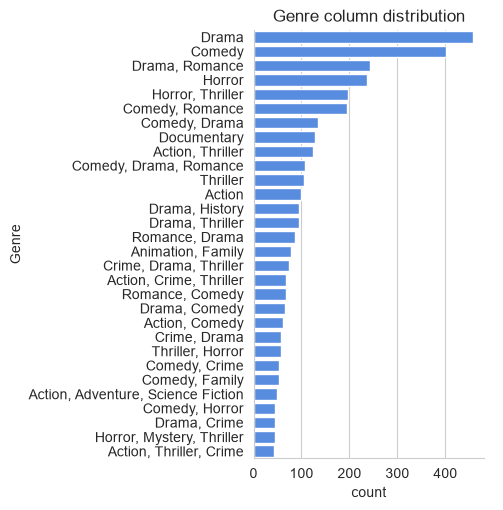

In [116]:
sns.catplot(y='Genre',data=df,kind='count',
            order=df['Genre'].value_counts().head(30).index,
            color='#4287f5')
plt.title('Genre column distribution')
plt.show()

# which has highest votes in vote avg column ?

In [102]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,release_Date,genre
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction",2021-12-15,"[Action, Adventure, Science Fiction]"
1,1970,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller",2022-03-01,"[Crime, Mystery, Thriller]"
2,1970,No Exit,2618.087,122,below_avg,Thriller,2022-02-25,[Thriller]
3,1970,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy",2021-11-24,"[Animation, Comedy, Family, Fantasy]"
4,1970,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War",2021-12-22,"[Action, Adventure, Thriller, War]"


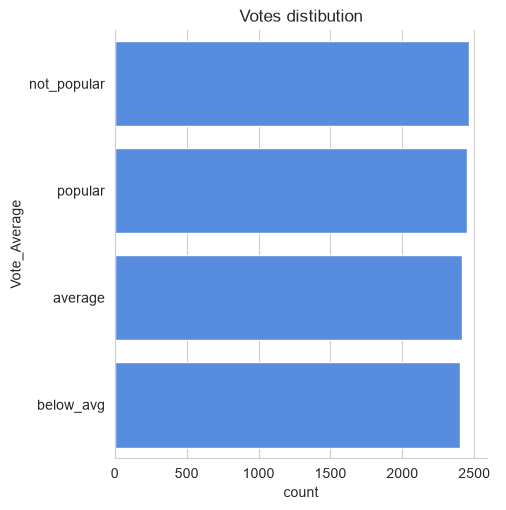

In [105]:
sns.catplot(y='Vote_Average',data=df,kind='count',
             order=df['Vote_Average'].value_counts().head(35).index,
            color='#4287f5')
plt.title('Votes distibution')
plt.show()

# what movie got the highest popularity? what's its genre?

In [106]:
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,release_Date,genre
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction",2021-12-15,"[Action, Adventure, Science Fiction]"
1,1970,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller",2022-03-01,"[Crime, Mystery, Thriller]"


In [107]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,release_Date,genre
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction",2021-12-15,"[Action, Adventure, Science Fiction]"


 # what movie got the lowest popularity? what's its genre?

In [111]:
df[df['Popularity']==df['Popularity'].min()]


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,release_Date,genre
9725,1970,The United States vs. Billie Holiday,13.354,152,average,"Music, Drama, History",2021-03-31,"[Music, Drama, History]"
9726,1970,Threads,13.354,186,popular,"War, Drama, Science Fiction",1984-09-23,"[War, Drama, Science Fiction]"


#                      Conclusions

# Q1: What is the most frequent genre in the dataset?
Drama genre is the most frequent genre in our dataset and has appeared more than
14% of the times among 19 other genres.
# Q2: What genres has highest votes ?
# we have 25.5% of our dataset with popular vote (6520 rows). Drama again gets the
highest popularity among fans by being having more than 18.5% of movies popularities.
# Q3: What movie got the highest popularity ? what's its genre ?
Spider-Man: No Way Home has the highest popularity rate in our dataset and it has
genres of Action , Adventure and Sience Fiction .
# Q3: What movie got the lowest popularity ? what's its genre ?
The united states, thread' has the highest lowest rate in our dataset
and it has genres of music , drama , 'war', 'sci-fi' and history`.
